In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [11]:
# loading the data from csv file to a Pandas DataFrame.
df = pd.read_csv("insurance.csv")
print(df)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


In [29]:
# Column Descriptions

# Independent Variables

#1) Age(Numerical Column) :- Age tells us how old the person is.
#  It is an important factor because medical expenses usually increase as people grow older.

#2) Sex(Categoriacal Column) :- Sex tells us whether the person is male or female.
#  This column is a categorical variable.


#3) BMI(Body Mass Index)(Numerical Column) :- BMI shows whether a person has a healthy body weight based on height and weight.
# BMI is a numerical feature and plays an important role in predicting insurance charges.

#4) ChildrenNumerical Column) :- This column tells how many children (dependents) the person has.
# This is a Numerical Variable.
# It helps the model understand how family size affects medical insurance costs.

#5) Smoker(Categorical Column) :- This column shows whether the person smokes or not.
# This is a categorical variable.
# It is one of the most important features affecting Insurance Charges.

#6) Region(Categorical Column) :- Region tells the area where the person lives (for example: southeast, southwest, etc.).
# This is a Categorical Variable.

#  Dependent Variable / Output Feature :- 
# Charges(Numerical Column) :- Charges represent the medical insurance cost billed to the person.
# This is the value we want to predict using Linear Regression.
# It is a Continuous Numerical Value.

## EDA on this Dataset.

In [6]:
# Get the Quick Overview of the Dataset and Understand the structure of the Dataset.

df.shape  # Rows and Columns of the Dataset.
print("Infornmation about the Dataset")
df.info() # Complete Infornmation about the Columns of the Dataset.
df.columns # Infornmation i.e. Names of the Columns about the Dataset.
df.head(5) # Top 5 Rows of the Dataset.
df.tail(5) # Last 5 Rows of the Dataset.
df.dtypes # Getting Data - Types of each Column in the Dataset.
df.count()  # Count Non-Null Values in Each Column.
df.dtypes # Determining the Data - type of Columns in the Dataset.

Infornmation about the Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [7]:
# Checking for the Missing Vaues i.e. find out the Missing Values.

print(df.isnull()) # Null - Values in the form of Boolean Matrix(True - Missing Values , False - Not a mssing Values).
print(df.notnull()) # Opposite of isnull(True - Not a Missing Values , False - Missing Values)
print(df.isnull().sum()) # Count of the Missing Values of each Columns.
# By illustration, it is clear there are no missing values in any column in the Dataset.

        age    sex    bmi  children  smoker  region  charges
0     False  False  False     False   False   False    False
1     False  False  False     False   False   False    False
2     False  False  False     False   False   False    False
3     False  False  False     False   False   False    False
4     False  False  False     False   False   False    False
...     ...    ...    ...       ...     ...     ...      ...
1333  False  False  False     False   False   False    False
1334  False  False  False     False   False   False    False
1335  False  False  False     False   False   False    False
1336  False  False  False     False   False   False    False
1337  False  False  False     False   False   False    False

[1338 rows x 7 columns]
       age   sex   bmi  children  smoker  region  charges
0     True  True  True      True    True    True     True
1     True  True  True      True    True    True     True
2     True  True  True      True    True    True     True
3     True 

In [8]:
# Handling Duplicates in the Dataset.

print(df.duplicated())  # Reurns a Boolean series i.e. True denotes Duplicate Value and False denotes Not a Duplicate Value.
print(df.duplicated().sum()) # Sum of the Duplicate Values of the rows in the dataset(415 here).
df = df.drop_duplicates() #Dropping the Duplicate Rows in the Dataset.
print(df)

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool
1
      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1337 rows x 

## Univariate Analysis

## age Column

In [12]:
df['age'].describe() # Statisical Summary of age Column

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

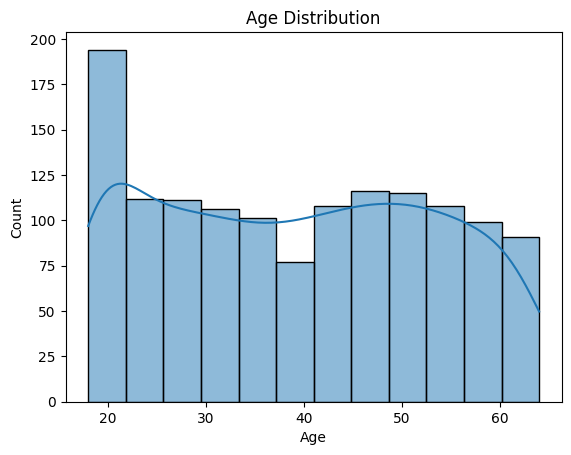

In [13]:
# Histogram

sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

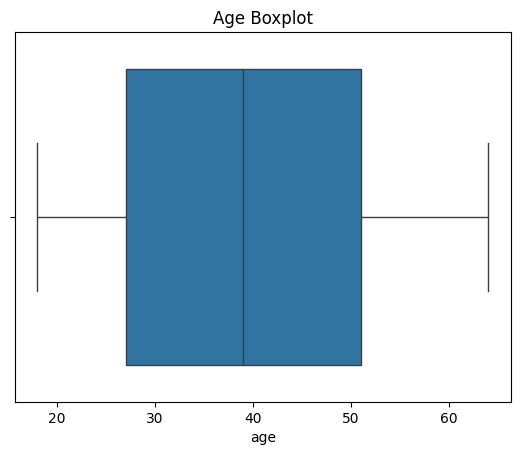

In [14]:
# Boxplot

sns.boxplot(x=df['age'])
plt.title("Age Boxplot")
plt.show()

## sex Column

In [15]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

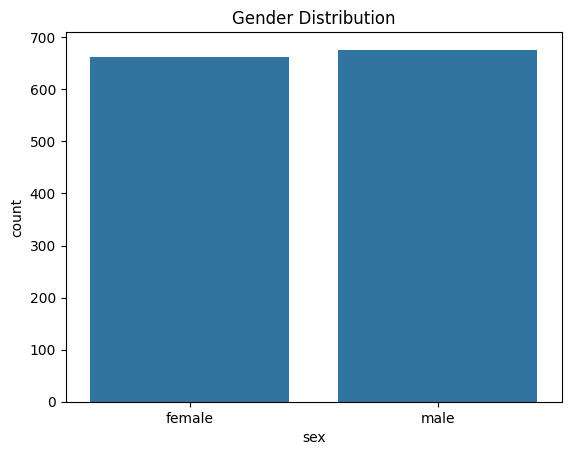

In [16]:
# Countplot(Shows Distribution of male vs female.

sns.countplot(x='sex', data=df)
plt.title("Gender Distribution")
plt.show()

## bmi Column



In [17]:
df['bmi'].describe()  # Statisical Summary of bmi Column

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

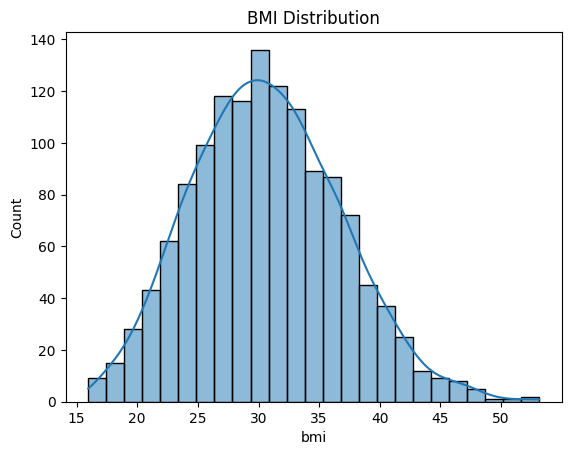

In [18]:
# Histogram

sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

Normal BMI Range --> 18.5 to 24.9

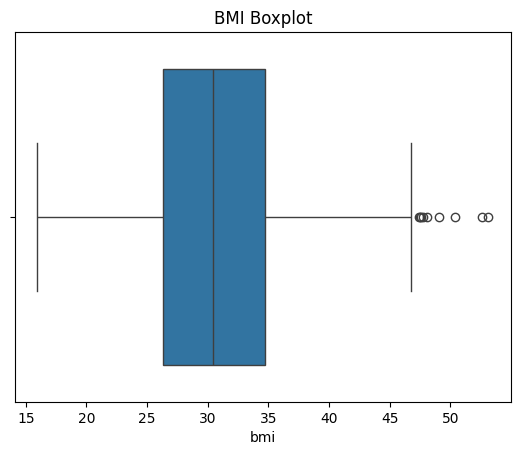

In [19]:
# Boxplot

sns.boxplot(x=df['bmi'])
plt.title("BMI Boxplot")
plt.show()

## smoker Column

In [20]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

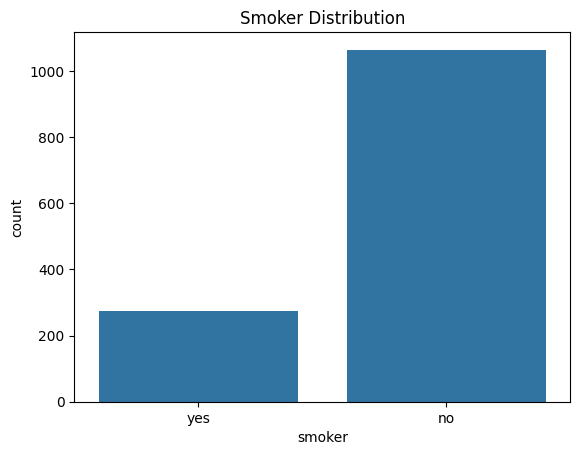

In [21]:
# Countplot

sns.countplot(x='smoker', data=df)
plt.title("Smoker Distribution")
plt.show()

## region Column

In [30]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

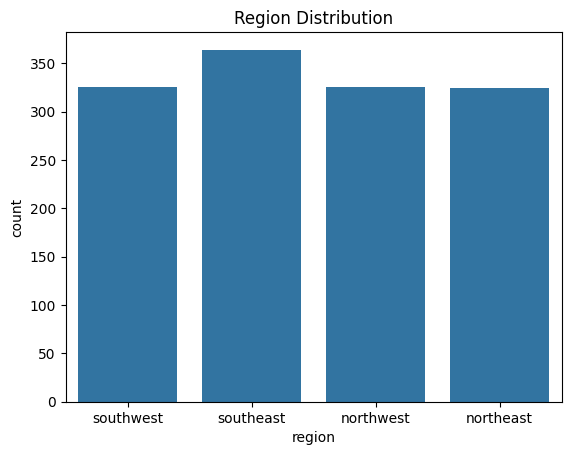

In [31]:
# Countplot

sns.countplot(x='region', data=df)
plt.title("Region Distribution")
plt.show()

## Bivariate Analysis

## age vs charges Columns

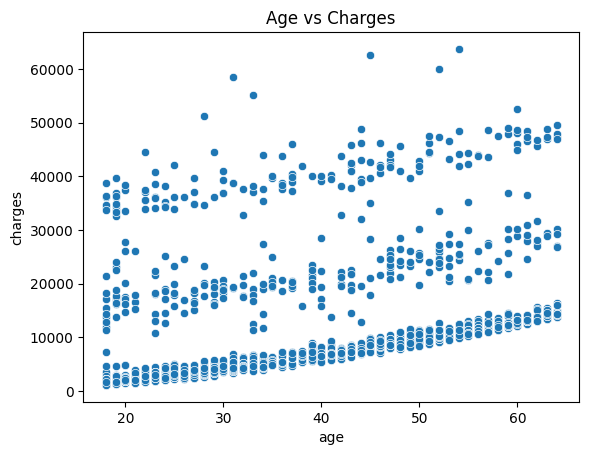

In [22]:
# Scatterplot

sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

In [23]:
# Correlation

df[['age', 'charges']].corr()

,age,charges
age,1.000000,0.299008
charges,0.299008,1.000000


## bmi vs charges columns

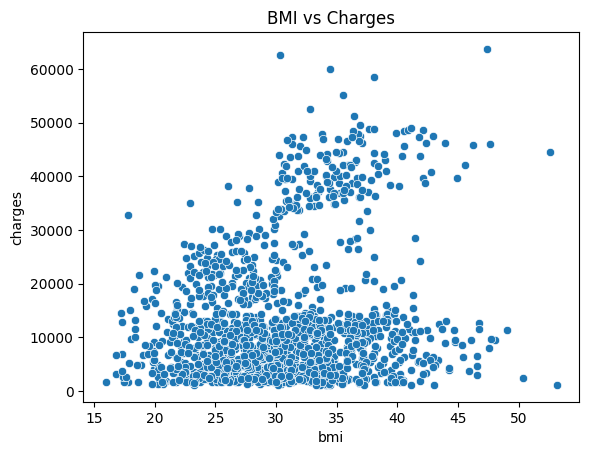

In [26]:
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()


In [27]:
# Correlation

df[['bmi', 'charges']].corr()

,bmi,charges
bmi,1.000000,0.198341
charges,0.198341,1.000000


## Feature Engineering

In [32]:
# Encoding sex column
df.replace({'sex': {'male': 0, 'female': 1}}, inplace=True)

# Encoding smoker column
df.replace({'smoker': {'yes': 0, 'no': 1}}, inplace=True)

# Encoding region column
df.replace({'region': {
    'southeast': 0,
    'southwest': 1,
    'northeast': 2,
    'northwest': 3
}}, inplace=True)


C:\Users\abhis\AppData\Local\Temp\ipykernel_1224\3673586595.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'sex': {'male': 0, 'female': 1}}, inplace=True)
C:\Users\abhis\AppData\Local\Temp\ipykernel_1224\3673586595.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'smoker': {'yes': 0, 'no': 1}}, inplace=True)
C:\Users\abhis\AppData\Local\Temp\ipykernel_1224\3673586595.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavi

In [33]:
print(df)

      age  sex     bmi  children  smoker  region      charges
0      19    1  27.900         0       0       1  16884.92400
1      18    0  33.770         1       1       0   1725.55230
2      28    0  33.000         3       1       0   4449.46200
3      33    0  22.705         0       1       3  21984.47061
4      32    0  28.880         0       1       3   3866.85520
...   ...  ...     ...       ...     ...     ...          ...
1333   50    0  30.970         3       1       3  10600.54830
1334   18    1  31.920         0       1       2   2205.98080
1335   18    1  36.850         0       1       0   1629.83350
1336   21    1  25.800         0       1       1   2007.94500
1337   61    1  29.070         0       0       3  29141.36030

[1338 rows x 7 columns]


In [35]:
# Splitting Features and Target

X = df.drop(columns='charges', axis=1)
Y = df['charges']

In [36]:
print("Features (X):")
print(X.head())

Features (X):
   age  sex     bmi  children  smoker  region
0   19    1  27.900         0       0       1
1   18    0  33.770         1       1       0
2   28    0  33.000         3       1       0
3   33    0  22.705         0       1       3
4   32    0  28.880         0       1       3


In [38]:
print("\nTarget (Y):")
print(Y.head())


Target (Y):
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


## Splitting the data into Training data & Testing Data

In [39]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [40]:
print(X.shape, X_train.shape, X_test.shape)

(1338, 6) (1070, 6) (268, 6)


## Model Training(Linear Regression Model)

In [42]:
# loading the Linear Regression model.

regressor = LinearRegression()

In [43]:
regressor.fit(X_train, Y_train)

LinearRegression()

## Model Evaluation

In [44]:
# prediction on training data
training_data_prediction =regressor.predict(X_train)

# R squared value
r2_train = metrics.r2_score(Y_train, training_data_prediction)
print('R squared vale : ', r2_train)

R squared vale :  0.751505643411174


An R² value of 0.7515 indicates that approximately 75.15% of the variance in insurance charges is explained by the independent variables in the model, which suggests a good model fit.

In [45]:
# prediction on test data
test_data_prediction =regressor.predict(X_test)

# R squared value
r2_test = metrics.r2_score(Y_test, test_data_prediction)
print('R squared vale : ', r2_test)

R squared vale :  0.7447273869684077


The testing R² score of 0.7447 indicates that the model explains approximately 74.47% of the variance in insurance charges on unseen data. 
Since this value is very close to the training R² score, the model does not suffer from overfitting or underfitting and generalizes well.

## Building a Predictive System

In [48]:
# Example input data
# (age, sex, bmi, children, smoker, region)
# sex: male=0, female=1
# smoker: yes=0, no=1
# region: southeast=0, southwest=1, northeast=2, northwest=3

input_data = (31, 1, 25.74, 0, 1, 0)

# Convert to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# Reshape (because model expects 2D array)
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# Prediction using trained model
prediction = regressor.predict(input_data_reshaped)

print("Predicted Insurance Cost:", prediction[0])

Predicted Insurance Cost: 3760.0805764960587


C:\Users\abhis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
